In [1]:
!pip install pyspark

In [2]:
!wget -O data.gz "https://go.criteo.net/criteo-research-kaggle-display-advertising-challenge-dataset.tar.gz"

--2026-03-08 03:25:39--  https://go.criteo.net/criteo-research-kaggle-display-advertising-challenge-dataset.tar.gz
Resolving go.criteo.net (go.criteo.net)... 74.119.118.85, 2620:100:a005::25
Connecting to go.criteo.net (go.criteo.net)|74.119.118.85|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://criteostorage.blob.core.windows.net/criteo-research-datasets/kaggle-display-advertising-challenge-dataset.tar.gz [following]
--2026-03-08 03:25:40--  https://criteostorage.blob.core.windows.net/criteo-research-datasets/kaggle-display-advertising-challenge-dataset.tar.gz
Resolving criteostorage.blob.core.windows.net (criteostorage.blob.core.windows.net)... 20.209.1.1
Connecting to criteostorage.blob.core.windows.net (criteostorage.blob.core.windows.net)|20.209.1.1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4576820670 (4.3G) [application/x-gzip]
Saving to: ‘day_0.gz’

day_0.gz            100%[===================>]   4.26G  27.5

In [14]:
!tar -zxvf /content/data.gz

tar: Ignoring unknown extended header keyword 'SCHILY.dev'
tar: Ignoring unknown extended header keyword 'SCHILY.ino'
tar: Ignoring unknown extended header keyword 'SCHILY.nlink'
readme.txt
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.creationtime'
tar: Ignoring unknown extended header keyword 'SCHILY.dev'
tar: Ignoring unknown extended header keyword 'SCHILY.ino'
tar: Ignoring unknown extended header keyword 'SCHILY.nlink'
test.txt
tar: Ignoring unknown extended header keyword 'SCHILY.dev'
tar: Ignoring unknown extended header keyword 'SCHILY.ino'
tar: Ignoring unknown extended header keyword 'SCHILY.nlink'
train.txt


In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Criteo_MMDS_Benchmarking") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.driver.maxResultSize", "2g") \
    .getOrCreate()

print("Spark Version:", spark.version)

Spark Version: 4.0.2


In [26]:
from pyspark.sql.types import StructType, StructField, IntegerType, StringType

fields = [StructField("label", IntegerType(), True)]

for i in range(1, 14):
    fields.append(StructField(f"I{i}", IntegerType(), True))

for i in range(1, 27):
    fields.append(StructField(f"C{i}", StringType(), True))

criteo_schema = StructType(fields)

print(len(criteo_schema.fields))

40


In [27]:
df_raw = spark.read.csv("train.txt", sep='\t', schema=criteo_schema)

df_sample = df_raw.sample(withReplacement=False, fraction=0.05, seed=42)

df_sample.cache()

print("samples:", df_sample.count())
df_sample.show(20)

samples: 2291189
+-----+----+----+----+----+-----+----+---+---+---+----+---+----+----+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+
|label|  I1|  I2|  I3|  I4|   I5|  I6| I7| I8| I9| I10|I11| I12| I13|      C1|      C2|      C3|      C4|      C5|      C6|      C7|      C8|      C9|     C10|     C11|     C12|     C13|     C14|     C15|     C16|     C17|     C18|     C19|     C20|     C21|     C22|     C23|     C24|     C25|     C26|
+-----+----+----+----+----+-----+----+---+---+---+----+---+----+----+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+
|    1|   1| 987|NULL|   2|  105|   2|  1|  2|  2|   1|  1|NULL|   2|68

In [28]:
df_sample.describe().show()

+-------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------------------+--------+--------+--------------------+--------+--------+--------+--------+--------------------+-----------+--------+--------------------+--------+
|summary|             label|                I1|                I2|                I3|               I4|                I5|                I6|                I7|               I8|                I9|               I10|               I11|               I12|               I13|      C1|      C2|      C3|      C4|      C5|      C6|      C7|      C8|      C9|     C10|     C11|     C12|     C13|                 C14|     C15|     C16|            

In [29]:
df_sample.groupBy("label").count().show()

+-----+-------+
|label|  count|
+-----+-------+
|    1| 587533|
|    0|1703656|
+-----+-------+



In [30]:
import pyspark.sql.functions as F

exprs = [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df_sample.columns]

null_counts_df = df_sample.select(exprs)

null_counts_df.show()

+-----+-------+---+------+------+-----+------+-----+----+-----+-------+-----+-------+------+---+---+-----+-----+---+------+---+---+---+---+---+-----+---+---+---+-----+---+---+-------+-------+-----+-------+---+-----+-------+-------+
|label|     I1| I2|    I3|    I4|   I5|    I6|   I7|  I8|   I9|    I10|  I11|    I12|   I13| C1| C2|   C3|   C4| C5|    C6| C7| C8| C9|C10|C11|  C12|C13|C14|C15|  C16|C17|C18|    C19|    C20|  C21|    C22|C23|  C24|    C25|    C26|
+-----+-------+---+------+------+-----+------+-----+----+-----+-------+-----+-------+------+---+---+-----+-----+---+------+---+---+---+---+---+-----+---+---+---+-----+---+---+-------+-------+-----+-------+---+-----+-------+-------+
|    0|1040026|  0|492406|496845|59198|513264|99103|1147|99103|1040026|99103|1752794|496845|  0|  0|77784|77784|  0|276836|  0|  0|  0|  0|  0|77784|  0|  0|  0|77784|  0|  0|1009228|1009228|77784|1746942|  0|77784|1009228|1009228|
+-----+-------+---+------+------+-----+------+-----+----+-----+-------+-

spark to pandas...


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


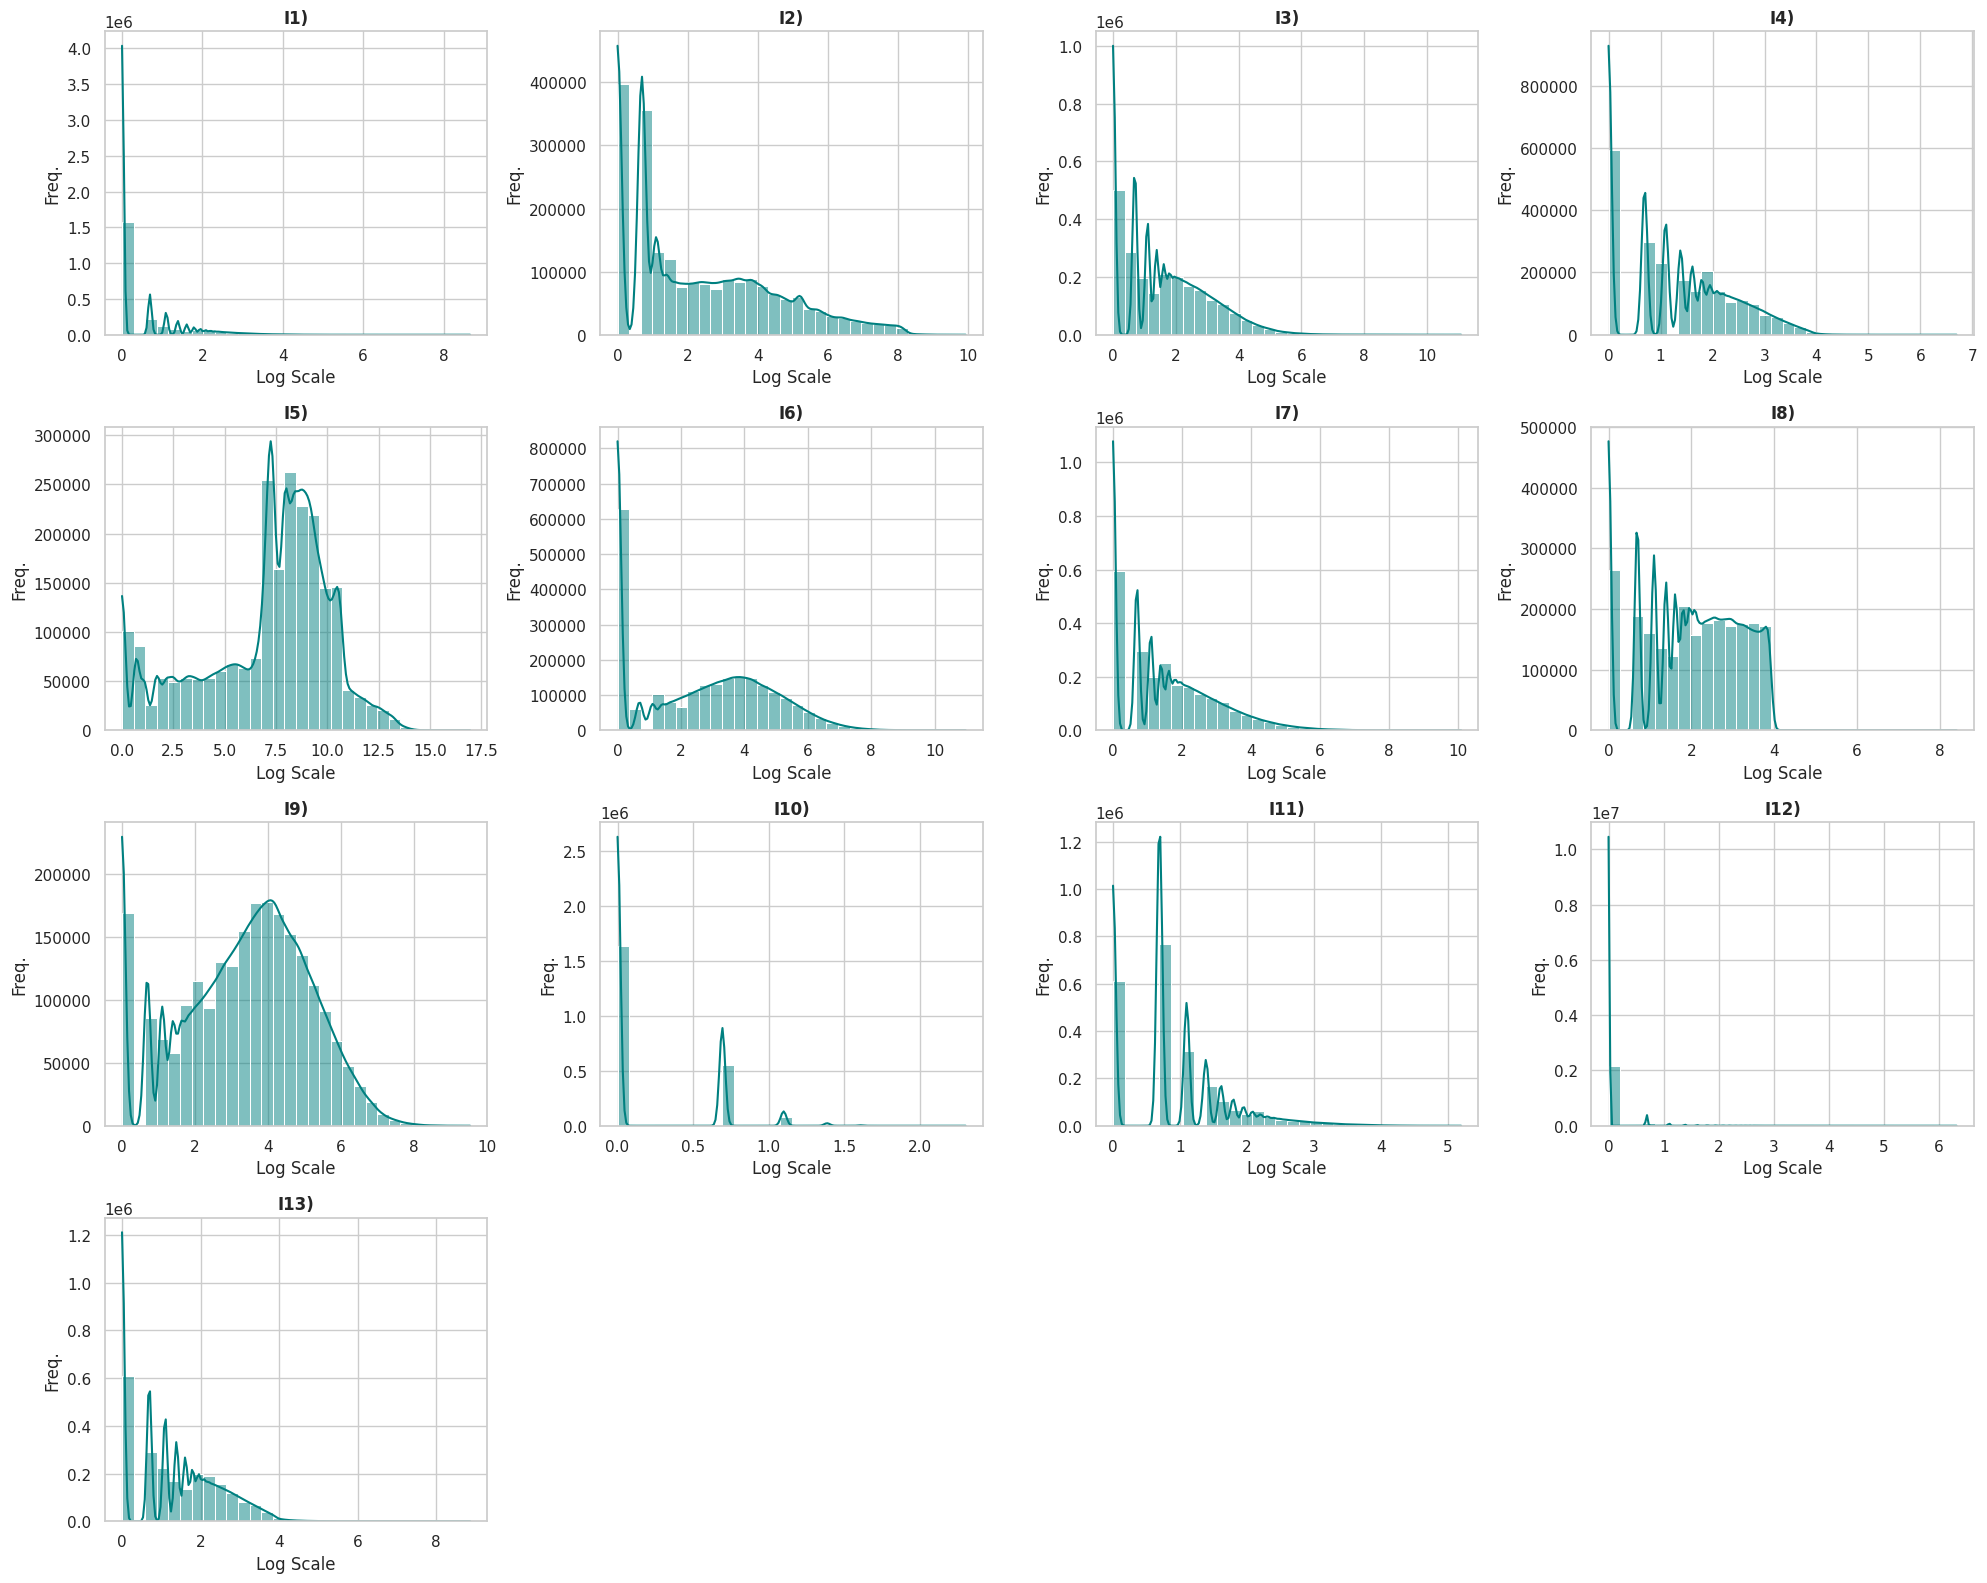

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

num_cols = [f"I{i}" for i in range(1, 14)]

print("spark to pandas...")
# demo with nan = 0
df_num_spark = df_sample.select(num_cols).fillna(0)
pdf = df_num_spark.toPandas()

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    plot_data = np.log1p(pdf[col]) #log(1+x)

    sns.histplot(plot_data, bins=30, ax=axes[i], kde=True, color="teal")

    axes[i].set_title(f"{col})", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Log Scale")
    axes[i].set_ylabel("Freq.")

for j in range(13, 16):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()